<a href="https://colab.research.google.com/github/URTD14/from-scratch/blob/main/Deep_Learning_using_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a neural net from scratch

In [ ]:
import numpy as np

#1 derive sigmoid function (pushes the values to 0-1 , best for binary prediction)
def sigmoid(x):
  return 1 / (1 + np.exp(-np.clip(x,-250,250))) #np.clip() to avoid overflow

def sigmoid_derivative(x):
  s = sigmoid(x)
  return s * (1-s)

#creating the neural net
class SimpleNN:
  def __init__(self, input_size=2,hidden_size=4,output_size=1,learning_rate=0.1):

    #randomly initialize weights and bias
    self.W1 = np.random.randn(input_size,hidden_size) * np.sqrt(2.0 / input_size)
    self.b1 = np.zeros((1,hidden_size))
    self.W2 = np.random.randn(hidden_size,output_size) * np.sqrt(2.0 / hidden_size)
    self.b2 = np.zeros((1,output_size))
    self.lr = learning_rate

#forward passing to compute predictions
  def forward(self,X):

  #hidden layer: X ( W1 + b1) then sigmoid func
    self.z1 = np.dot(X, self.W1) + self.b1
    self.a1 = sigmoid(self.z1)

  #output layer: a1 (W2 + b2) then sigmoid func
    self.z2 = np.dot(self.a1,self.W2) + self.b2
    self.a2 = sigmoid(self.z2)
    return self.a2

#backward pass: update weights via backpropagation

  def backward(self,X,y,output):

    m = X.shape[0] #batch size
    dz2 = output - y #for binary cross entropy with sigmoid
    dW2 = (1/m) * np.dot(self.a1.T,dz2)
    db2 = (1/m) * np.sum(dz2,axis=0,keepdims=True)

  #hidden layer ( propagate back)

    da1 = np.dot(dz2,self.W2.T)
    dz1 = da1 * sigmoid_derivative(self.z1)
    dW1 = (1/m) * np.dot(X.T,dz1)
    db1 = (1/m) * np.sum(dz1,axis=0,keepdims=True)

  #update weights (gradient descent)
    self.W2 -= self.lr * dW2
    self.b2 -= self.lr * db2
    self.W1 -= self.lr * dW1
    self.b1 -= self.lr * db1

#training the network

  def train(self,X,y,epochs=1000):
    for epoch in range(epochs):
    #forward
      output = self.forward(X)
    #backward
      self.backward(X,y,output)
    #loss
      if epoch % 1000 == 0:
        loss = np.mean(y * np.log(output + 1e-8) + (1-y) * np.log(1-output + 1e-8))
        print(f"Epoch {epoch}, Loss: {loss}")

# preparing XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

#create and train the NN
nn = SimpleNN(input_size=2,hidden_size=4,output_size=1,learning_rate=0.1)
nn.train(X,y,epochs=10000)

#make predictions
predictions = nn.forward(X)
print("Predictions:")
print(predictions)

# accuracy
accuracy = np.mean(np.round(predictions) == y)
print(f"Accuracy: {accuracy}")
print("\n YOOO LFG WE BUILT OUR NN FROM SCRATCH XDDD")

Epoch 0, Loss: -0.7638694844412626
Epoch 1000, Loss: -0.6905140884958483
Epoch 2000, Loss: -0.6588380838322501
Epoch 3000, Loss: -0.5116609368133646
Epoch 4000, Loss: -0.2378168171108828
Epoch 5000, Loss: -0.09414051222152237
Epoch 6000, Loss: -0.05236462254878349
Epoch 7000, Loss: -0.03519132418095494
Epoch 8000, Loss: -0.026185372739735657
Epoch 9000, Loss: -0.02072500148546171
Predictions:
[[0.01473824]
 [0.98310433]
 [0.98528872]
 [0.02141671]]
Accuracy: 1.0

 YOOO LFG WE BUILT OUR NN FROM SCRATCH XDDD


# PyTorch

refer this repo: https://github.com/mrdbourke/pytorch-deep-learning

Intro to Tensors


Tensors can represent data of various dimensions, from 0-dimensional scalars to 1-dimensional vectors, 2-dimensional matrices, and higher-dimensional arrays. This allows them to effectively encode diverse data types like images, text, and numerical datasets.

GPU Acceleration: Unlike NumPy arrays, PyTorch Tensors can be seamlessly moved to and operated on GPUs (Graphics Processing Units), significantly accelerating numerical computations, which is crucial for training large deep neural networks.

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.9.0+cu126


In [ ]:
scalar = torch.tensor(7)
scalar

tensor(7)

In [ ]:
vector = torch.tensor([7,7])
vector

tensor([7, 7])

In [ ]:
matrix = torch.tensor([[7,8],[9,10]])
matrix

tensor([[ 7,  8],
        [ 9, 10]])

In [ ]:
#ndim is used to return number of dimensions
print(scalar.ndim)
print(vector.ndim)
print(matrix.ndim)
print(vector.shape)
print(matrix.shape)

0
1
2
torch.Size([2])
torch.Size([2, 2])


In [ ]:
tensor = torch.tensor([[1,2,3],
                       [3,6,9],
                       [2,4,5]])
print(tensor)
print(tensor.ndim)
print(tensor.shape)

tensor([[1, 2, 3],
        [3, 6, 9],
        [2, 4, 5]])
2
torch.Size([3, 3])


In [ ]:
"""
   random tensors : these are imp cuz many neural networks learn is that they start with tensors full of random numbers
   and then adjust those random numbers to better represent the data.
   start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers
"""

rand_tensor = torch.rand(3,4)
rand_tensor

tensor([[0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411, 0.4294]])

In [ ]:
#creating a random tensor with similar shape to an img tensor

rand_img_size_tensor = torch.rand(size = (224,224,3))  #height,width,color(RGB)
rand_img_size_tensor.shape, rand_img_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

In [ ]:
zeros = torch.zeros(size = (3,4))
zeros

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [ ]:
zeros * rand_tensor

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [ ]:
#ones
ones = torch.ones(size=(3,4))
print(ones)
print(ones.dtype)


tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
torch.float32


In [ ]:
#creating range of tensors

range = torch.arange(start = 0,end=100,step=7)
range

tensor([ 0,  7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 77, 84, 91, 98])

In [ ]:
#creating tensors alike

alike = torch.zeros_like(input=range)
alike

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
#tensor datatypes

float_32 = torch.tensor([3.6,7.6,9.0],dtype=None,device=None,requires_grad=False)
float_32.dtype

torch.float32

In [ ]:
float_16 = float_32.type(torch.float16)
float_16


tensor([3.5996, 7.6016, 9.0000], dtype=torch.float16)

In [ ]:
int_32 = torch.tensor([3,6,9],dtype=torch.int32)
int_32

tensor([3, 6, 9], dtype=torch.int32)

In [ ]:
#manipulating tensors

tensor = torch.tensor([1,23,3])
print(tensor + 10)
print(tensor * 10)
print(tensor - 10)
print(tensor / 10)

tensor([11, 33, 13])
tensor([ 10, 230,  30])
tensor([-9, 13, -7])
tensor([0.1000, 2.3000, 0.3000])


In [ ]:
#trying inbuilt math functions
tensor = torch.tensor([1,2,3])
print(torch.mul(tensor,10))
print(torch.add(tensor,10))
print(torch.sub(tensor,10))
print(torch.div(tensor,10))

tensor([10, 20, 30])
tensor([11, 12, 13])
tensor([-9, -8, -7])
tensor([0.1000, 0.2000, 0.3000])


In [ ]:
#tensor matrix multiplication
matrix1 = torch.tensor([[1,2,3],[2,3,4],[6,8,9]])
matrix2 = torch.tensor([[1,2,3],[3,7,9],[5,2,9]])

torch.matmul(matrix1,matrix2) #u can also use torch.mm

tensor([[ 22,  22,  48],
        [ 31,  33,  69],
        [ 75,  86, 171]])

In [ ]:
#transposing the matrices
matrix1_T = matrix1.T
print(matrix1_T)

tensor([[1, 2, 6],
        [2, 3, 8],
        [3, 4, 9]])


In [ ]:
#finding min,max,sum etc
tensor = torch.arange(0,100,10)
print(tensor.max())
print(tensor.min())
print(tensor.sum())

tensor(90)
tensor(0)
tensor(450)


In [ ]:
#for finding mean() the tensor must be in float or complex dtype
print(tensor.type(torch.float32).mean())

tensor(45.)


In [ ]:
#using argmin() : returns the position of target tensor where min value occurs and argmax does the vice  versa
print(tensor.argmin())
print(tensor.argmax())

tensor(0)
tensor(9)


In [ ]:
 #reshaping,restacking,squeezing and unsqueezing tensors

"""
for stacking there are 3 type of stacks
let's see each of them"""

x = torch.arange(1.,10.)
print(x, x.shape)

#add an extra dimension ( reshape)
x_reshaped = x.reshape(1,9)
print(x_reshaped, x_reshaped.shape)

#changeing the view
z = x.view(1,9)
print(z, z.shape) # if we change z , x will also change

#applying all type of stacks
x_stacked = torch.stack([x,x,x,x],dim=1)
print(x_stacked)

#applying squeeze
x_squeezed = x_reshaped.squeeze()
print(x_squeezed, x_squeezed.shape)

#unsqueezing
x_unsqueezed = x_squeezed.unsqueeze(dim=0)
print(x_unsqueezed, x_unsqueezed.shape)


tensor([1., 2., 3., 4., 5., 6., 7., 8., 9.]) torch.Size([9])
tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]) torch.Size([1, 9])
tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]) torch.Size([1, 9])
tensor([[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.],
        [4., 4., 4., 4.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
        [7., 7., 7., 7.],
        [8., 8., 8., 8.],
        [9., 9., 9., 9.]])
tensor([1., 2., 3., 4., 5., 6., 7., 8., 9.]) torch.Size([9])
tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]) torch.Size([1, 9])


In [ ]:
#permute = rearranges the the dimensions of the target tensor in a specific order

x_original = torch.rand(size=(224,224,3)) #height,width,color channel(RGB)
print('x_original:',x_original.shape)

#when we apply permute the shape changes from colorchannels,height,width
x_permuted = x_original.permute(2,0,1) #shifts axis 0->1, 1->2, 2->0 : here 2 = color channel, 0 = height,1=width
print('x_permuted:',x_permuted.shape)

x_original: torch.Size([224, 224, 3])
x_permuted: torch.Size([3, 224, 224])


In [ ]:
#indexing

x = torch.arange(1,10).reshape(1,3,3)
print(x,x.shape)

#indexing on dim=1(middle bracket)
print(x[0][0])

#indexing on last bracket
print(x[0] [2] [1])

#there is also another method ( this is quite faster than above one)

print(x[:,0])
print(x[:,:,1]) #get all values of 0th and 1th dimension but only index 1 of 2nd dimension

#get all the values of 0th dimension but 1 value of 1st & 2nd dimension
print(x[:,1,1])

#get 0 of 0th and 1st dimension and all values of 2nd dimension
print(x[0,0,:])

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]]) torch.Size([1, 3, 3])
tensor([1, 2, 3])
tensor(8)
tensor([[1, 2, 3]])
tensor([[2, 5, 8]])
tensor([5])
tensor([1, 2, 3])


this indexing is quite confusing so watch the below eg and you'll learn it easily


[1, 2, 3],

[4, 5, 6],
         
[7, 8, 9]

--> x.shape = (1,3,3) : 1 batch, 3 rows, 3 columns


if someone asks print 7 using this indexing then u'll be confused but not now ,see below

print(x[0, 2, 0])

7 is at:

Batch 0 → x[0]

Row 2 → x[0, 2]


Column 0 → x[0, 2, 0]




"Batch" is the 1st dimension in almost all PyTorch (and deep learning) tensors.

So:

Batch size = 1 → you have one 3×3 image/matrix


If batch size was 4 → you would have four 3×3 images stacked together


--------------------------------------------------------------------------------


Torch tensors and NumPy

In [ ]:
import torch
import numpy

array = np.arange(1.0,8.0)
tensor = torch.from_numpy(array).type(torch.float32) #numpy has dtype of float64 for float value as default
print(array,tensor)
print('changed to float32:',tensor.dtype)


[1. 2. 3. 4. 5. 6. 7.] tensor([1., 2., 3., 4., 5., 6., 7.])
changed to float32: torch.float32


In [ ]:
#tesor to numpy array
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor,numpy_tensor,numpy_tensor.dtype

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32),
 dtype('float32'))

In [ ]:
#reproducibilty (taking out random out of random)

tensor_A = torch.rand(3,3)
tensor_B = torch.rand(3,3)
print(tensor_A)
print(tensor_B)
print(tensor_A == tensor_B)
# to reduce this randomness pytorch as random seed just like numpy

random_seed = 42
torch.manual_seed(random_seed)
random_tensor_C = torch.rand(3,3)
random_tensor_D = torch.rand(3,3)
print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)

tensor([[0.0323, 0.8270, 0.8660],
        [0.2001, 0.7926, 0.1140],
        [0.6855, 0.0086, 0.3588]])
tensor([[0.9211, 0.8627, 0.8223],
        [0.5248, 0.5881, 0.2746],
        [0.3791, 0.2975, 0.6450]])
tensor([[False, False, False],
        [False, False, False],
        [False, False, False]])
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
tensor([[0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739]])
tensor([[False, False, False],
        [False, False, False],
        [False, False, False]])


1) Building real torch model with synthetic data

/tmp/ipython-input-2065883555.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X,y,cmap='coolwarm')


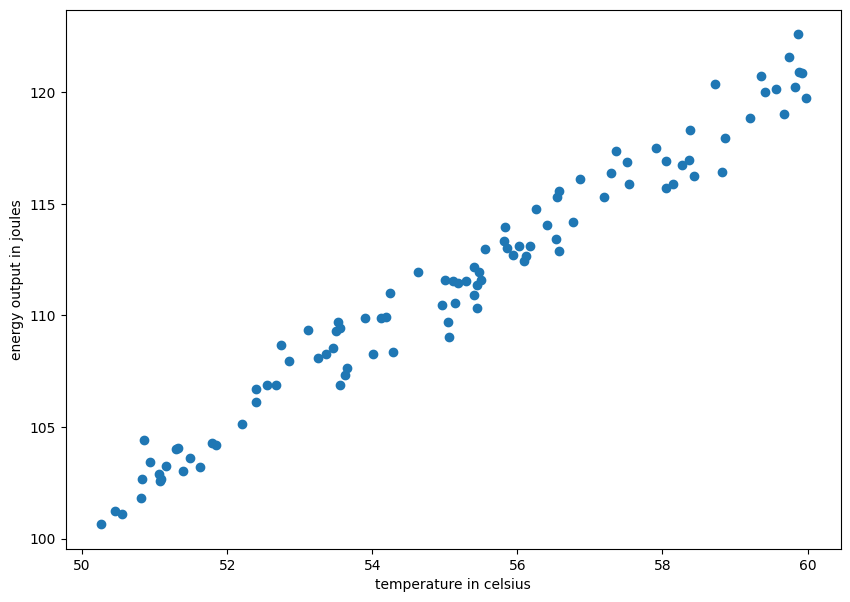

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

# Generate sample data: y = 2x + 1 + noise (linear relationship with some randomness)
torch.manual_seed(42)
X = torch.from_numpy(np.random.rand(100,1).astype(np.float32)) * 10 + 50 #100 samples, temps around 50°C
y = 2 * X + 1 + torch.randn(100,1)

#visualize
plt.figure(figsize=(10,7))
plt.scatter(X,y,cmap='coolwarm')
plt.xlabel('temperature in celsius')
plt.ylabel('energy output in joules')
plt.show()


In [ ]:
#splitting the data into train tests
train_split = int(0.8*len(X))
X_train,y_train = X[:train_split], y[:train_split]
X_test,y_test = X[train_split:], y[train_split:]

print(f"train samples : {len(X_train)} , test samples : {len(X_test)}")

#this approach is quite faster than using sklearn's train_test_split for tensors

train samples : 80 , test samples : 20


In [ ]:
#create the main part of the model
class LinearRegression(nn.Module):
  def __init__(self): #with the we can call LinearRegression() many times
    super().__init__() # Calls parent's init—registers submodules/parameters automatically

    # Initialize learnable parameters (what the model "learns")
    self.linear_layer = nn.Linear(in_features=1 #here tempearature is the input feature
                            ,out_features=1) #here energy is the output feature

  def forward(self,x:torch.Tensor)->torch.Tensor: # Defines how data flows through the model
        # Must implement forward()—PyTorch calls it implicitly when you do model(x)

    return self.linear_layer(x)

In [ ]:
#inspecting the model
torch.manual_seed(42)
model_0 = LinearRegression()

#looking at the paramters
print(list(model_0.parameters()))
print(model_0.state_dict())

[Parameter containing:
tensor([[0.7645]], requires_grad=True), Parameter containing:
tensor([0.8300], requires_grad=True)]
OrderedDict({'linear_layer.weight': tensor([[0.7645]]), 'linear_layer.bias': tensor([0.8300])})


In [ ]:
#predicting
with torch.inference_mode(): # Disables grad tracking—saves memory/speed for pure prediction
  y_preds = model_0(X_test) #calls forward() implicitly
print(f"predictions shape: {y_preds.shape}, sample: {y_preds[:3]}")

predictions shape: torch.Size([20, 1]), sample: tensor([[46.3692],
        [44.2311],
        [46.4562]])


refer this link for loss functions

https://docs.pytorch.org/docs/stable/nn.html#loss-functions

In [ ]:
#loss functions and optimizers
"""
think of them like this : Loss = "How wrong are predictions?" Optimizer = "How to fix it?"""

loss_fn = nn.L1Loss()  # Mean Absolute Error (MAE): avg |pred - true|—robust to outliers
optimizer = torch.optim.Adam(params=model_0.parameters()#wht to update
                            ,lr=0.01)

In [ ]:
#training the model
"""
   This is the engine: Repeat "forward → loss → backward → update" until convergence. """

#setup for tracking
epochs = 100
#storing the metrics
train_losses = []
test_losses = []

#training loop

for epoch in range(epochs):

  # Phase 1: Training mode (enables dropout/batchnorm if any—none here, but good habit)
  model_0.train()

  #forward pass : predict on the train data
  y_pred = model_0(X_train)

  #compute the loss
  loss = loss_fn(y_pred,y_train)
  train_losses.append(loss.item()) #.item() extracts scalar from vector

  #backward pass: zero old gradients
  optimizer.zero_grad()

  #backpropagation
  loss.backward()

  #update params:
  optimizer.step()

  #evaluation
  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss = loss_fn(test_pred,y_test)
    test_losses.append(test_loss.item())

  #print out whats happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | loss {loss} test_loss: {test_loss}")


#plotting

plt.figure(figsize=(10,7))
plt.plot(train_losses,label='train loss')
plt.plot(test_losses,label='test loss')
plt.xlabel('epoch')
plt.ylabel('L1 loss')
plt.title('Model training: loss over time')
plt.legend()
plt.show()


print('loss',test_loss)


"""
   Line-by-Line Breakdown:

-for epoch in range(epochs):: Loops over dataset (here, full pass per epoch—mini-batches for big data).
-model_0.train(): Sets mode. Enables trainable layers.
-y_pred = model_0(X_train): Forward—compute preds.
-loss = loss_fn(y_pred, y_train): Scalar loss value.
-optimizer.zero_grad(): Reset gradients to zero—PyTorch accumulates by default.
-loss.backward(): The calculus! Computes ∂Loss/∂weights, etc., via chain rule. Stores in .grad.
-optimizer.step(): Updates: param = param - lr * grad.
-model_0.eval() + with torch.inference_mode():: For test—no grads, pure forward.
-test_loss = ...: Track overfitting (if test loss rises while train falls).
"""

TypeError: 'Tensor' object is not callable

In [ ]:
#final evaluation
with torch.inference_mode():
  y_preds = model_0(X_test).detach().numpy()
  y_test_np = y_test.numpy()

plt.figure(figsize=(10,7))
plt.scatter(X_test,y_test,cmap='coolwarm',s=4,label='y_test')
plt.plot(X_test, y_preds, c='red', label='Predicted Line')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Output')
plt.legend()
plt.title('Model Fit: Predictions vs. y_test')
plt.show()

# Metrics: Lower is better
print(f"Final Test Loss: {test_losses[-1]:.4f}")

In [ ]:
#saving the models
from pathlib import Path
# Create models directory if it doesn't exist
Path("models").mkdir(parents=True, exist_ok=True)
torch.save(obj=model_0.state_dict(),f=Path("models/01_pytorch.pth"))

In [ ]:
#loading the model,for this we have to create another instance
loaded_model_0 = LinearRegression()
loaded_model_0.load_state_dict(torch.load(f=Path("models/01_pytorch.pth")))

Now let's make an multi layered neural network to predict non linear data

/tmp/ipython-input-4108442452.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X,y,cmap='gray',alpha=0.6,label='data points')


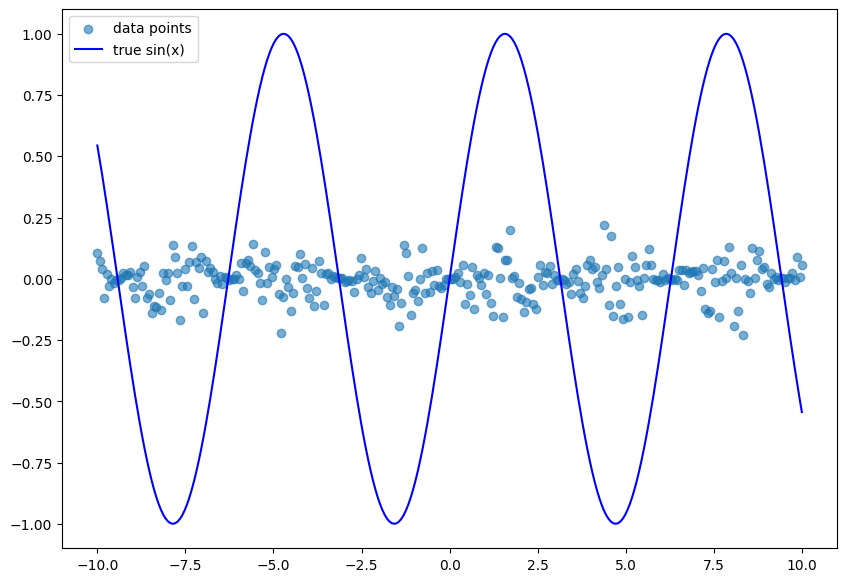

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# =============================================
# 1. Generate Non-Linear Data (Sine Wave + Noise)
# =============================================
torch.manual_seed(42)  # Reproducibility

X = torch.linspace(-10,10,300).unsqueeze(1)
y = torch.sin(X) * 0.1 * torch.randn_like(X) #curvy non linear data
#training the data

train_split = int(0.8*len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

#visualizing

plt.figure(figsize=(10,7))
plt.scatter(X,y,cmap='gray',alpha=0.6,label='data points')
plt.plot(X,torch.sin(X),c='blue',label='true sin(x)')
plt.legend()
plt.show()

In [ ]:
class MLP(nn.Module):
  def __init__(self,input_size=1,hidden_size=64,output_size=1):
    super().__init__()

    #using nn.sequential
    self.layers = nn.Sequential(
        nn.Linear(in_features = input_size, out_features = hidden_size),
        nn.ReLU(), # for non-linearity we use ReLU
        nn.Linear(in_features=hidden_size,out_features=hidden_size), #hidden 1 -> hidden 2
        nn.ReLU(),
        nn.Linear(in_features=hidden_size,out_features=output_size)
      )

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.layers(x)


model_mlp = MLP(input_size=1,hidden_size=64,output_size=1)

print(model_mlp)
print(f"total parameters: {sum(p.numel()for p in model_mlp.parameters())}")

MLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
total parameters: 4353


In [ ]:
#training the model

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(params=model_mlp.parameters(),lr=0.01)
epochs = 500
train_losses = []
test_losses = []

for epoch in range(epochs):
  model_mlp.train()

  y_pred = model_mlp(X_train)
  loss = loss_fn(y_pred,y_train)
  train_losses.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_mlp.eval()
  with torch.inference_mode():
    test_pred = model_mlp(X_test)
    test_loss = loss_fn(test_pred,y_test)
    test_losses.append(test_loss.item())

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | train loss: {loss.item()} | test_loss: {test_loss.item()} ")

print("Completed")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (800x2 and 1x64)

In [ ]:
model_mlp.eval()
with torch.inference_mode():
  y_preds = model_mlp(X)

plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.plot(test_losses,label='test loss')
plt.plot(train_losses,label='train loss')
plt.xlabel('epochs')
plt.ylabel("MSE loss")
plt.legend()


plt.subplot(1,2,2)
plt.scatter(X,y,cmap='gray',alpha=0.6,label='data points')
plt.plot(X,torch.sin(X),c='blue',label='true sin(x)')
plt.plot(X,y_preds,c='red',linewidth=3,label='MLP Prediction')
plt.legend()
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1000x2 and 1x64)

Now we will go into CLASSIFICATION

There are mainly three types of classification

1) Binary 2. Multiclass 3. Multilabel

let's code it first for binary then we'll jump onto multiclass

In [ ]:
import torch
import sklearn
from sklearn.datasets import make_circles
from torch import nn


In [ ]:
n_samples = 1000

#making circles
X,y = make_circles(n_samples=n_samples,noise=0.03,random_state=42)

print(X.shape,y.shape)

(1000, 2) (1000,)


         X1        X2  label
0  0.754246  0.231481      1
1 -0.756159  0.153259      1
2 -0.815392  0.173282      1
3 -0.393731  0.692883      1
4  0.442208 -0.896723      0


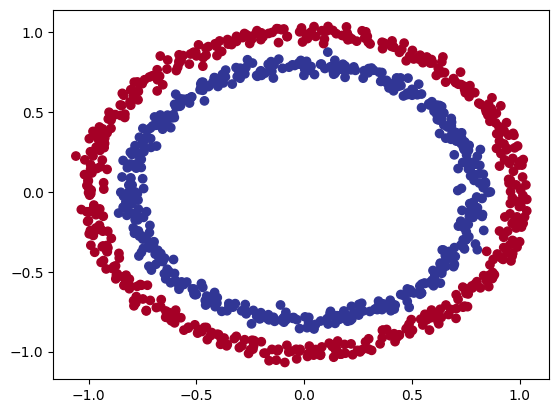

In [ ]:
#making dataframe of this circles
import pandas as pd

circles = pd.DataFrame({"X1": X[:,0],
                        "X2":X[:,1],
                        "label":y})
print(circles.head())

#visualizing
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)
plt.show()

In [ ]:
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

#training the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train,y_train

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]]),
 tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
         0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1.,
         1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1.,
         1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0.,
         0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,


In [ ]:
class circleModel2(nn.Module):
  def __init__(self):
    super().__init__()

    self.two_layers = nn.Sequential(
        nn.Linear(in_features=2,out_features=32),
        nn.ReLU(),
        nn.Linear(in_features=32,out_features=64),
        nn.ReLU(),
        nn.Linear(in_features=64,out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128,out_features=1)
    )
    #LOL created a large neural net but this gonna predict the non linear data so its good
  def forward(self,x):
    return self.two_layers(x)

model_1 = circleModel2()
model_1.state_dict()

OrderedDict([('two_layers.0.weight',
              tensor([[ 0.6808,  0.6576],
                      [ 0.6506, -0.4379],
                      [ 0.6428, -0.5907],
                      [-0.5111, -0.2486],
                      [ 0.6927, -0.1989],
                      [ 0.2834, -0.0829],
                      [ 0.3585,  0.4171],
                      [ 0.6376,  0.4110],
                      [ 0.5702,  0.6362],
                      [ 0.2558,  0.4992],
                      [ 0.6097,  0.3099],
                      [-0.2286,  0.5323],
                      [ 0.1123,  0.4351],
                      [-0.2184, -0.6575],
                      [-0.4337, -0.0352],
                      [-0.4701, -0.2946],
                      [ 0.3555,  0.2550],
                      [-0.2067, -0.0287],
                      [-0.6721, -0.0367],
                      [-0.0250, -0.4371],
                      [ 0.6408, -0.3483],
                      [ 0.1001, -0.4798],
                      [ 0.1390, -0.5316

In [ ]:
#making predictions with untrained data
untrained_preds = model_1(X_test)
print(f"untrained preds: {torch.round(untrained_preds[:5])}")
print(f"y_test: {y_test[:5]}")
print("\n without training the predictions are so bad asf lol")

untrained preds: tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]], grad_fn=<RoundBackward0>)
y_test: tensor([1., 0., 1., 0., 1.])

 without training the predictions are so bad asf lol


In [ ]:
#Logits is the unnormalized final scores of your model. You apply softmax to it to get a probability distribution over your classes.
#think of logits as raw outputs

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)

In [ ]:
#calculating accuracy
def accuracy(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc


In [ ]:
#training the model
""" our model outputs are going to be raw Logits
    then we will convert these logits into prediction probabilities
    here our logits are X_test features """
model_1.eval()
with torch.inference_mode():
  y_logits = model_1(X_test[:5])
print("logits:",y_logits)

#now let's use sigmoid activation function to turn these logits into prediction probabilities
y_prob = torch.sigmoid(y_logits)
print(torch.round(y_prob))


epochs = 1000

for epoch in range(epochs):
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)
  acc = accuracy(y_true=y_train,y_pred=y_pred) #logits -> pred probs -> pred labels

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy(y_true=y_test,y_pred=y_prob)

  if epoch % 100 == 0:
    print(f"Epoch:{epoch} | loss: {loss:.5f} | Acc: {acc:.3f} % | test_loss: {test_loss:.5f} | test_acc: {test_acc}")



logits: tensor([[-0.0369],
        [-0.0524],
        [-0.0237],
        [-0.0459],
        [-0.0125]])
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]])
Epoch:0 | loss: 0.69453 | Acc: 49.500 % | test_loss: 0.69407 | test_acc: 0.0
Epoch:100 | loss: 0.68903 | Acc: 65.625 % | test_loss: 0.68963 | test_acc: 0.0
Epoch:200 | loss: 0.68007 | Acc: 74.750 % | test_loss: 0.68255 | test_acc: 0.0
Epoch:300 | loss: 0.65725 | Acc: 80.500 % | test_loss: 0.66509 | test_acc: 0.0
Epoch:400 | loss: 0.57276 | Acc: 91.750 % | test_loss: 0.59543 | test_acc: 0.0
Epoch:500 | loss: 0.46826 | Acc: 66.625 % | test_loss: 0.52916 | test_acc: 0.0
Epoch:600 | loss: 0.33567 | Acc: 82.250 % | test_loss: 0.42201 | test_acc: 0.0
Epoch:700 | loss: 0.04994 | Acc: 100.000 % | test_loss: 0.07926 | test_acc: 0.0
Epoch:800 | loss: 0.02321 | Acc: 100.000 % | test_loss: 0.04290 | test_acc: 0.0
Epoch:900 | loss: 0.01429 | Acc: 100.000 % | test_loss: 0.02969 | test_acc: 0.0


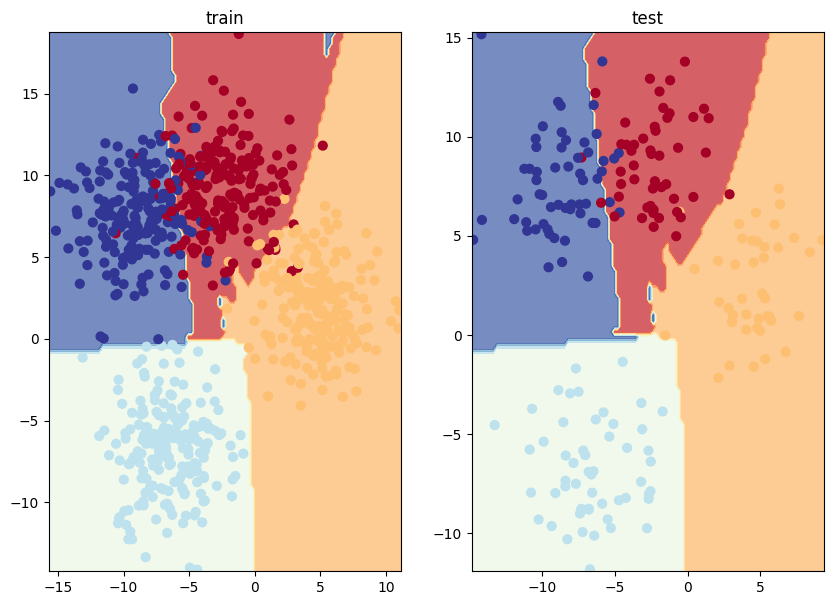

In [ ]:
import numpy as
def plot_decision_boundary(model, X, y):
    # Put everything to CPU (since plotting is usually done on CPU)
    X, y = X.cpu(), y.cpu()

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                           np.linspace(y_min, y_max, 100))

    # Make features for prediction
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on)

    # Turn predictions from logits -> prediction probabilities -> prediction labels
    y_pred = torch.round(torch.sigmoid(y_logits)).squeeze()

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)


plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title('train')
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title('test')
plot_decision_boundary(model_1,X_test,y_test)
plt.show()

Now let's try with multi class classification

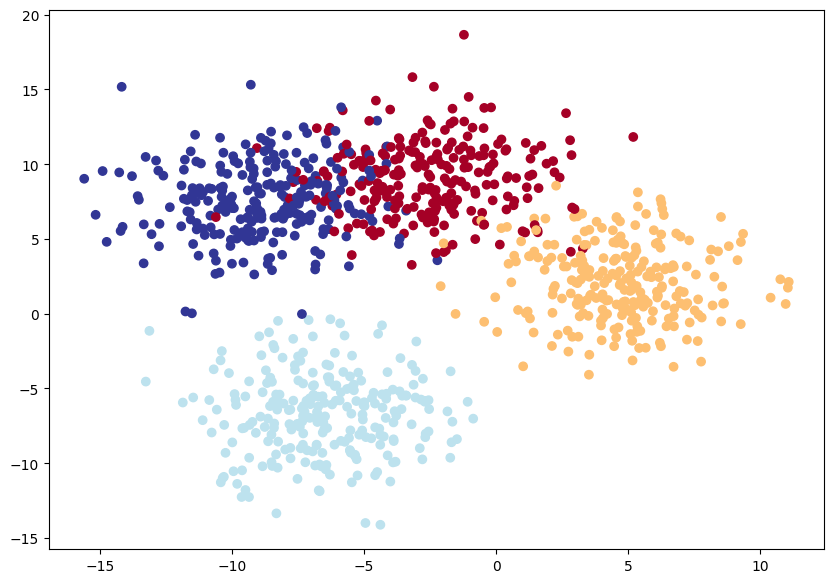

In [ ]:
#create the toy multiclass dataset
import torch
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

n_samples = 1000

#create the multiclass
X_blob,y_blob = make_blobs(n_samples=n_samples,n_features=2,centers=4,cluster_std=2.5,random_state=42)

X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.long) # Corrected to torch.long for CrossEntropyLoss

X_train,X_test,y_train,y_test = train_test_split(X_blob,y_blob,test_size=0.2,random_state=42) # Corrected unpacking order

#plotting data

plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)
plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cpu


In [ ]:
#building the model
class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units):
    super().__init__()

    self.layer = nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )

  def forward(self,x):
    return self.layer(x)

model_blob = BlobModel(input_features=2,output_features=4,hidden_units=32)


In [ ]:
#creating loss functions and optimizer
loss_fn = nn.CrossEntropyLoss() #FOR multiclass we use this
optimizer = torch.optim.Adam(params=model_blob.parameters(),lr=0.1)

In [ ]:
torch.manual_seed(42)

epochs = 1500

for epoch in range(epochs):
  model_blob.train()

  y_logits = model_blob(X_train)
  y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

  loss = loss_fn(y_logits,y_train)
  acc = accuracy(y_true=y_train,y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_blob.eval()
  with torch.inference_mode():
    test_logits = model_blob(X_test)
    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy(y_true=y_test,y_pred=test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.5f} | Accuracy: {acc:2f} ")

Epoch: 0 | loss: 0.22362 | Accuracy: 91.250000 
Epoch: 100 | loss: 0.16149 | Accuracy: 94.375000 
Epoch: 200 | loss: 0.15946 | Accuracy: 93.875000 
Epoch: 300 | loss: 0.15628 | Accuracy: 93.875000 
Epoch: 400 | loss: 0.15596 | Accuracy: 93.875000 
Epoch: 500 | loss: 0.15795 | Accuracy: 94.500000 
Epoch: 600 | loss: 0.15723 | Accuracy: 93.750000 
Epoch: 700 | loss: 0.16245 | Accuracy: 93.625000 
Epoch: 800 | loss: 0.15476 | Accuracy: 93.625000 
Epoch: 900 | loss: 0.15480 | Accuracy: 93.625000 
Epoch: 1000 | loss: 0.15482 | Accuracy: 93.750000 
Epoch: 1100 | loss: 0.15530 | Accuracy: 93.500000 
Epoch: 1200 | loss: 0.15429 | Accuracy: 93.750000 
Epoch: 1300 | loss: 0.15418 | Accuracy: 93.625000 
Epoch: 1400 | loss: 0.15430 | Accuracy: 93.750000 


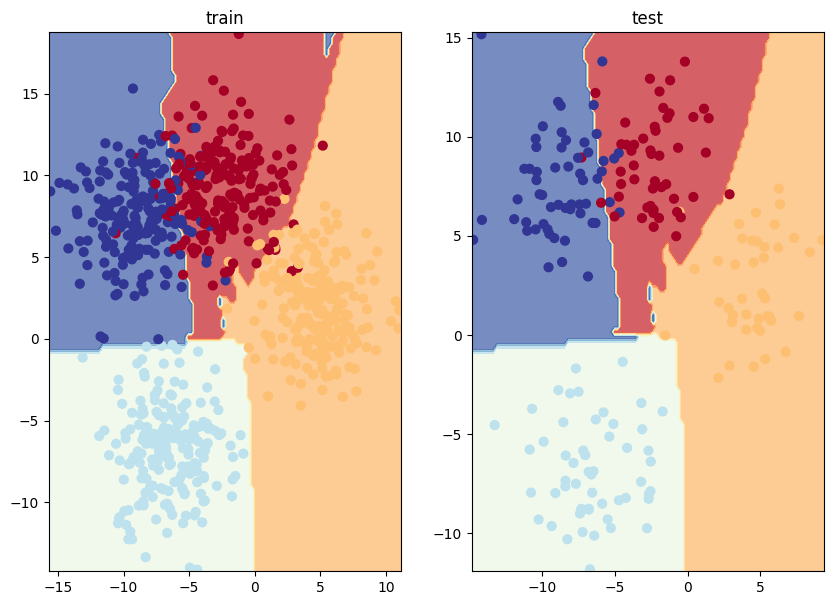

In [ ]:
#visualizing results

import numpy as np
def plot_decision_boundary(model, X, y):
    # Put everything to CPU (since plotting is usually done on CPU)
    X, y = X.cpu(), y.cpu()

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                           np.linspace(y_min, y_max, 100))

    # Make features for prediction
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on)

    # Turn predictions from logits -> prediction probabilities -> prediction labels
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)


plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title('train')
plot_decision_boundary(model_blob,X_train,y_train)
plt.subplot(1,2,2)
plt.title('test')
plot_decision_boundary(model_blob,X_test,y_test)
plt.show()

In [ ]:
from torchmetrics import functional

functional.classification.multiclass_confusion_matrix(test_pred,y_test, num_classes=4)

tensor([[46,  1,  0,  2],
        [ 1, 40,  0,  0],
        [ 0,  0, 53,  0],
        [ 9,  0,  0, 48]])

Now let's dive into CNN model

note that we will build this model to level of SOTA(State Of The Art) model

In [ ]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets
from torchvision import transforms #using this transforms we can convert the img to tensors
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

#step-1 always do this !!
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")



Using device: cpu


In [ ]:
#DEFINE TRANSFORMS
train_transform = transforms.Compose([
    transforms.RandomRotation(7.5), #small rotations for orientation invariance
    transforms.RandomAffine(degrees=0,translate=(0.078,0.075),scale=(1 - 0.085,1 + 0.085)), #shifts and zooms for robustness
    transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5)) #standarize to [-1,1] for gradient stability
  ])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5))
])



In [ ]:
# we will be using which is inbuilt dataset available from pytorch , the dataset is fashion MNIST

train_data = torchvision.datasets.FashionMNIST(
    root='data', #where to download and keep data
    train=True, #we want the training data set
    download=True,
    transform =train_transform
)
test_data = torchvision.datasets.FashionMNIST(
    root='data',
    train=False, #because we want testing set not training
    download=True,
    transform = test_transform
)

len(train_data),len(test_data)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 313kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.9MB/s]


(60000, 10000)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}

 tensor([9, 0, 0,  ..., 3, 0, 5])
Image shape: torch.Size([1, 28, 28])  -> [color_channels,height,width] 


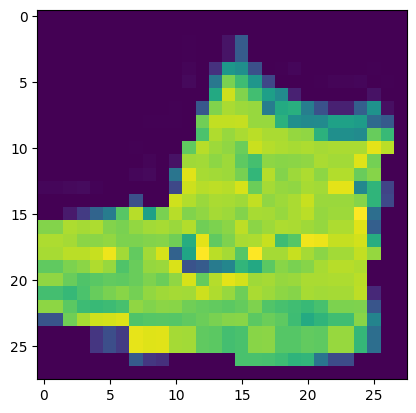

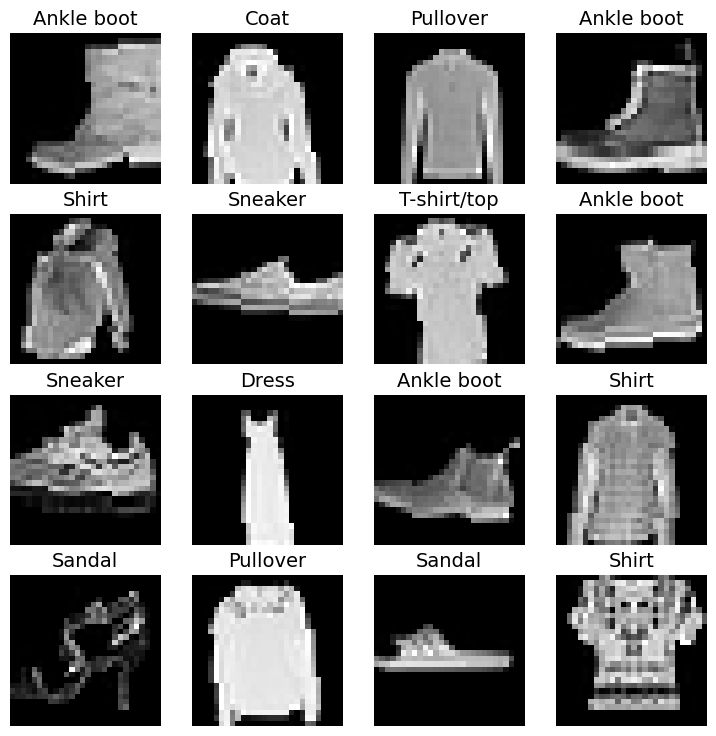

In [ ]:
class_names = train_data.classes
class_names
class_names = train_data.classes
print(class_names)

class_to_idx = train_data.class_to_idx
print(class_to_idx)
print("\n",train_data.targets)

image,label = train_data[0]
print(f"Image shape: {image.shape}  -> [color_channels,height,width] ")

#visualizing our data
plt.imshow(image.squeeze())

#now let's output random imgs
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img,label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap='gray')
  plt.axis(False);
  plt.title(class_names[label],fontsize=14)

Dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7a7c17aff560>
Length of train dataloader: 938
Length of test dataloader: 157
Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
Image shape: torch.Size([1, 28, 28])


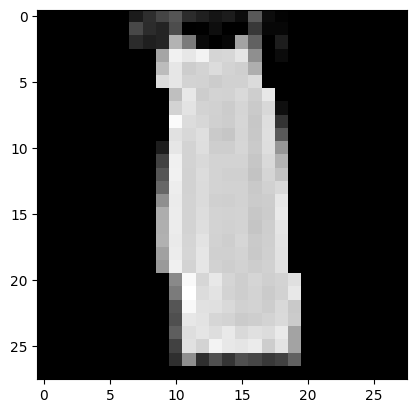

In [ ]:
#preparing the dataloader
""" means we will convert our data into batches
    like use few images at a time so this is more efficient and stores less memory """

train_loader = DataLoader(train_data,batch_size=64,shuffle=True) #shuffle = True cuz now this will mix all the images we have
test_loader = DataLoader(test_data,batch_size=64,shuffle=False) # we wont mix our test data as this is just for testing purpose nthn else

print(f"Dataloader: {train_loader}\nLength of train dataloader: {len(train_loader)}\nLength of test dataloader: {len(test_loader)}")

train_features_batch,torch_labels_batch = next(iter(train_loader))
print(f"Feature batch shape: {train_features_batch.size()}")
print(f"Labels batch shape: {torch_labels_batch.size()}")


random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img,label = train_features_batch[random_idx],torch_labels_batch[random_idx]
print(f"Image shape: {img.shape}")
plt.imshow(img.squeeze(),cmap='gray')

In [ ]:
flatten = nn.Flatten() #flatten multiplies height and width
flat_img = flatten(img)
print(f"Flattened image shape: {flat_img.shape}")

Flattened image shape: torch.Size([1, 784])


In [ ]:
#building the model
class FashionMNIST(nn.Module):
  def __init__(self):
    super(FashionMNIST,self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32,64,3,padding=1)
    self.bn2 = nn.BatchNorm2d(64)
    self.pool = nn.MaxPool2d(2,2)
    self.dropout = nn.Dropout(0.25) #Randomly zeros some neurons (during training only)
    self.fc1 = nn.Linear(64*7*7,128)
    self.fc2 = nn.Linear(128,10)

  def forward(self,x):
    x = self.pool(torch.relu(self.bn1(self.conv1(x))))
    x = self.pool(torch.relu(self.bn2(self.conv2(x))))
    x = x.view(-1,64*7*7) #Reshapes/flattens 4D tensor → 2D tensor
    x = torch.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x)
    return x

"""Conv → BatchNorm → ReLU → (optional: MaxPool)
Why this order became almost standard after ~2015–2016?

BatchNorm before activation → normalizes the input to the non-linearity
ReLU after normalization → avoids dying ReLU problem much more effectively
Having BatchNorm right after Conv helps gradients flow better through the network """

"""
Conv2D (2D Convolution) is a fundamental layer in Convolutional Neural Networks (CNNs) that applies learnable filters (kernels) across a 2D input
(like an image) to detect patterns, extract features (edges, textures), and produce a new 2D feature map

MaxPool2d (2D max pooling) is a downsampling operation used primarily in Convolutional Neural Networks (CNNs) that reduces the spatial dimensions
(height and width) of the input data by selecting the maximum value within a sliding rectangular window.  """



'\nConv2D (2D Convolution) is a fundamental layer in Convolutional Neural Networks (CNNs) that applies learnable filters (kernels) across a 2D input \n(like an image) to detect patterns, extract features (edges, textures), and produce a new 2D feature map\n\nMaxPool2d (2D max pooling) is a downsampling operation used primarily in Convolutional Neural Networks (CNNs) that reduces the spatial dimensions \n(height and width) of the input data by selecting the maximum value within a sliding rectangular window.  '

In [ ]:
model = FashionMNIST().to(device)
model


FashionMNIST(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
#setting up metrics and loss functions
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.001)

#LR-Scheduler - Reduce LR if loss stalls
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,mode='min',factor=0.1,patience=3)

In [ ]:
#training loop - add validation for scheduler
num_epochs = 1
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for images,labels in train_loader:
    images,labels = images.to(device),labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  avg_train_loss = running_loss / len(train_loader)

  #quick val loss for scheduler
  model.eval()
  val_loss = 0.0
  with torch.inference_mode():
    for images,labels in test_loader:
      images,labels = images.to(device),labels.to(device)
      outputs = model(images)
      val_loss += loss_fn(outputs,labels).item() # Corrected: 'criterion' changed to 'loss_fn'
    avg_val_loss = val_loss / len(test_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}: Train loss {avg_train_loss:.4f}, Val loss {avg_val_loss:.4f}")
#final evaluation
model.eval()
correct,total = 0,0
with torch.inference_mode():
  for images,labels in test_loader:
    images,labels = images.to(device),labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs,1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Upgraded Test Accuracy: {accuracy:.2f}%")

Epoch 1: Train loss 0.8230, Val loss 0.6326
Upgraded Test Accuracy: 76.77%


###RNN implementation

In [ ]:
class simplernn(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size

    self.W_xh = nn.Linear(input_size,hidden_size,bias=True) #Means: “weights from x (input) to h (hidden state)”
    self.W_hh = nn.Linear(hidden_size,hidden_size) #weights transfer from previous memory to new memory
    self.activation = nn.Tanh() #commonly used in RNNs

    #output
    self.W_hy = nn.Linear(hidden_size,output_size) #from new memory to output

  def forward(self,x,h0=None,return_sequence=False) #this structure supports external hidden states , many to one / many to many outputs
                            #return_sequence=False so it will print just one output but if True then it will print output at every timestep
    """
        x: (batch_size, sequence_length, input_size)
        h0: (batch_size, hidden_size)
        """

    batch_size,seq_len,input_size = x.shape

    #initualize hidden state (wht it does is if memory is not provided then it starts from zero or if provided then it starts from that point)
    if h0 is None:
      h_t = torch.zeros(batch_size,self.hidden_size,device = x.device)
    else:
      h_t = h0
    hidden_states = [] #to store many to many outputs

    for t in range(seq_len):
      x_t = x[:,t,:] #at t timestep it takes all the input and batch samples
      h_t = self.activation(
          self.W_xh(x_t) + self.W_hh(h_t) #final memory
      ) #we did this inside self.activation cuz this prevents exploding gradients and stabilizes them
      """
      self.W_xh(x_t)
      How much should the current input influence memory?

      self.W_hh(h_t)
      How much should the previous memory influence the current memory?
      """
      hidden_states.append(h_t.unsqueeze(1)) #store hidden state

      """
      Why unsqueeze(1)?

Because:

h_t shape is (batch_size, hidden_size)

we want (batch_size, 1, hidden_size)

so we can stack across time """

    hidden_states = torch.cat(hidden_states,dim=1) #we use "torch.cat()" as it will stack all the hidden states in the final output shape as (batch_size, sequence_length, hidden_size)


    if return_sequence:
      return self.W_hy(hidden_states)
    return self.W_hy(h_t)

    """
    Output logic
Case 1: many-to-many
if return_sequence:
    return self.W_hy(hidden_states)


Here:

hidden_states → (B, T, H)

W_hy maps each hidden state to output

Result:

(batch_size, sequence_length, output_size)


Used for:

sequence prediction

tagging

forecasting at every timestep

Case 2: many-to-one
return self.W_hy(h_t)

Here:

h_t is the final memory

represents entire sequence compressed into one vector

Result:

(batch_size, output_size)


Used for:

classification

regression

next-step prediction"""

GRU implementation

1) **reset gate formula:**
r
t
​
 =σ(W
r
​
 ⋅[h
t−1
​
 ,x
t
​
 ]) , σ is for sigmoid function

2) **update gate:**
z
t
​
 =σ(W
z
​
 ⋅[h
t−1
​
 ,x
t
​
 ])


3) **candidate hidden state:**
h
t
′
​
 =tanh(W
h
​
 ⋅[r
t
​
 ⋅h
t−1
​
 ,x
t
​
 ])


4) **hidden state**:
h
t
​
 =(1−z
t
​
 )⋅h
t−1
​
 +z
t
​
 ⋅h
t
′
​


-->***for more info visit this site for in-depth easy explanation***: https://towardsdatascience.com/the-math-behind-gated-recurrent-units-854d88aded65/

In [ ]:
class simplegru(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.hidden_size = hidden_size

    #update gate parameters , how much old memory should survive
    self.W_xz = nn.Linear(input_size,hidden_size)
    self.W_hz = nn.Linear(hidden_size,hidden_size)

    #reset gate parameters,should the past memory be forgotten while computing new one
    self.W_xr = nn.Linear(input_size,hidden_size)
    self.W_hr = nn.Linear(hidden_size,hidden_size)

    #cadidate state paramaters, new possible memory
    self.W_xh = nn.Linear(input_size,hidden_size)
    self.W_hh = nn.Linear(hidden_size,hidden_size)

    #output layer
    self.W_hy = nn.Linear(hidden_size,output_size)
    self.sigmoid = nn.Sigmoid()
    self.tanh = nn.Tanh()

  def forward(self,x,h0=None,return_sequence=False):
    batch_size,seq_len,_ = x.shape

    if h0 is None:
      h_t = torch.zeros(batch_size,self.hidden_size,device=x.device)
    else:
      h_t = h0

    hidden_states = []

    for t in range(seq_len):
      x_t = x[:,t,:]
      z_t = self.sigmoid(
          self.W_xz(x_t) + self.W_hz(h_t) #this interprets as (if z_t ~ 1->trust new memory ,if ~ 0 ->keep old memory)
      )

      r_t = self.sigmoid(
          self.W_xr(x_t) + self.W_hr(h_t) #same as above z_t just if it is ~ 1 _. use past fully or if ~ 0 -> ignore past
      )

      h_candidate = self.tanh(
          self.W_xh(x_t) + self.W_hh(r_t*h_t) #r_t*h_t means if reset gate is small then past memory is suppressed and model focusses on current input
      )

      h_t = (1-z_t)*h_t + z_t*h_candidate # (1-z_t)*h_t means the old memory + new inject memory(z_t*h_candidate), this is the final formula which produces the output
      hidden_states.append(h_t.unsqueeze(1))
      hidden_states = torch.cat(hidden_states,dim=1)
      if return_sequence:
        return self.W_hy(hidden_states)
      return self.W_hy(h_t)

biGRU implementation

In [ ]:
class BiGRU(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.foward_gru = simplegru(input_size,hidden_size,output_size)
    self.backward_gru = simplegru(input_size,hidden_size,output_size)

    self.W_out = nn.Linear(hidden_size * 2, output_size)

  def forward(self, x, return_sequence=False):
    h_fwd = self.forward_gru(x, return_sequence=True)
    b_fwd = self.backward_gru(torch.flip(x,dims=[1]),return_sequence=True)
    b_fwd = torch.flip(b_fwd,dims=[1])

    h_combined = torch.cat((h_fwd,b_fwd),dim=2)
    if return_sequence:
      return self.W_out(h_combined)
    return self.W_out(h_combined[:,-1,:])

lstm implementation

1) **forget gate**:

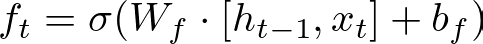


2) **input gate (it) and candidate state(Ct):**

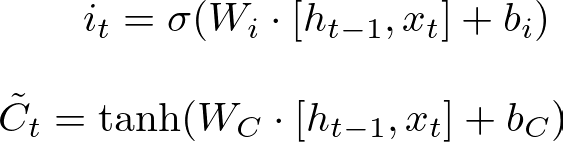

3) **update gate**:

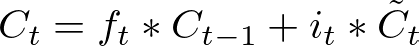

4) **output gate**:

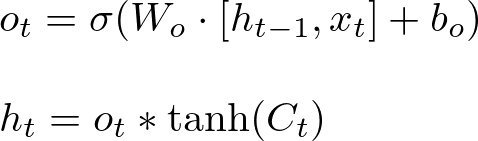


----> ***refer this site for in-depth easy explanation***: https://towardsdatascience.com/the-math-behind-lstm-9069b835289d/

In [ ]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden_size = hidden_size

        # Forget gate
        self.W_xf = nn.Linear(input_size, hidden_size)
        self.W_hf = nn.Linear(hidden_size, hidden_size)

        # Input gate
        self.W_xi = nn.Linear(input_size, hidden_size)
        self.W_hi = nn.Linear(hidden_size, hidden_size)

        # Candidate cell state
        self.W_xc = nn.Linear(input_size, hidden_size)
        self.W_hc = nn.Linear(hidden_size, hidden_size)

        # Output gate
        self.W_xo = nn.Linear(input_size, hidden_size)
        self.W_ho = nn.Linear(hidden_size, hidden_size)

        # Output layer
        self.W_hy = nn.Linear(hidden_size, output_size)

        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
  def forward(self,x,h0=None,return_sequence=False):
    batch_size,seq_len,_ = x.shape

    if h0 is None:
      h_t = torch.zeros(batch_size,self.hidden_size,device=x.device)
    else:
      h_t = h0

    if c0 is None:
      c_t = torch.zeros(batch_size,self.hidden_size,device=x.device)
    else:
      c_t = c0

    hidden_states = []

    for t in range(seq_len):
      x_t = x[:,t,:]
      f_t = self.sigmoid(
          self.W_xf(x_t) + self.W_hf(h_t) #which part of the old memory should survive
          )
      i_t = self.sigmoid(
          self.W_xi(x_t) + self.W_hi(h_t) #how much new info to be written
      )
      c_candidate = self.tanh(
          self.W_xc(x_t) + self.W_hc(h_t) #wht new info could be added
      )
      c_t = f_t * c_t + i_t * c_candidate #keep important old memory and add selected new memory
      o_t = self.sigmoid(
          self.W_xo(x_t) + self.W_ho(h_t) #how much memory should be exposed
      )

      h_t = o_t*self.tanh(c_t) #compress the memory -> filter it -> send to output
      hidden_states.append(h_t.unsqueeze(1))
    hidden_states = torch.cat(hidden_states,dim=1)
    if return_sequence:
      return hidden_states
    return self.W_hy(h_t)

BiLSTM implementation

In [ ]:
class BiLSTM(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.forward_lstm = LSTM(input_size,hidden_size,output_size)
    self.backward_lstm = LSTM(input_size,hidden_size,output_size)

    self.W_hy = nn.Linear(hidden_size*2, output_size)

    def forward(self,x,return_sequence=True):
      h_fwd = self.forward_lstm(x,return_sequence=True)

      b_fwd = self.backward_lstm(torch.flip(x,[1]),return_sequence=True)
      b_fwd = torch.flip(b_fwd,dims=[1])

      h_combined = torch.cat([h_fwd,b_fwd],dim=2)
      if return_sequence:
        return self.W_hy(h_combined)
      else:
        return self.W_hy(h_combined[:,-1,:])

Seq2Seq encoder and decoder


% wht does encoder do ?
  -> Reads the input sequence and compresses it into a context vector.

% wht does decoder do?
  -> Uses that understanding to generate output step by step.

% wht does sequence2sequence mean?

  Input is a sequence
  Output is also a sequence
  Lengths can be different

  Examples:

   English → French sentence

   Audio frames → text tokens

   Past prices → future prices

Indicators sequence → trade actions

In [ ]:
class encoder(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.gru = nn.gru(input_size,hidden_size,batch_size=True)
  def forward(self,x):
    _,h_n = self.gru(x) # "_" -> is all intermediate hidden states and "h_n" is the final hidden state
    return h_n

class decoder(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.gru = nn.gru(input_size,hidden_size,batch_first=True)
    self.fc = nn.Linear(hidden_size,output_size)
  def forward(self,x,h_n):
    x,h_n = self.gru(x,h_n) #this h_n is coming from the encoder
    x = self.fc(x) #maps hidden states to output eg: price,action,signal
    return x,h_n

#seq2seq wrapper
class seq2seq(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self,src,tgt):
    context = self.encoder(src)
    outputs,_ = self.decoder(tgt,context) #decoder uses context as initial memory
    return outputs